# Testing MPNN Models trained with ZINC and SPICE Datasets

## Zinc Dataset

In [1]:
from torch.utils.data import random_split
import numpy as np
import importlib
import logging

logging.basicConfig(
    level=logging.INFO,
    format='[%(asctime)s] %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler("dataset_loader.log"),
        logging.StreamHandler()
    ]
)

In [2]:
from atoMLtype.datasets.GNNdataset import GNNdataset
from atoMLtype.models.ModelEncoder import ModelEncoder

zinc_dataset_encoder = ModelEncoder(collapse=True)

# Load the ZINC files
zinc_sdf_path = "./data/parm_at_Frosst/zinc.sdf"
zinc_json_labels = "./data/antechamber/atomLabels_gaff2.json"

# Initialize dataset
zinc_dataset = GNNdataset(zinc_sdf_path, 
                              zinc_json_labels, 
                              directed_graph=True, 
                              labeled=True,
                              encoder=zinc_dataset_encoder)

[2025-04-22 19:33:26,157] INFO - Loaded atom type labels for 6410 molecules from ./data/antechamber/atomLabels_gaff2.json
[2025-04-22 19:33:26,201] WARNING - Atom count mismatch for ZINC03169274: 30 atoms in SDF, but 26 labels in JSON.
[2025-04-22 19:33:26,229] WARNING - Atom count mismatch for ZINC02569341: 19 atoms in SDF, but 34 labels in JSON.
[2025-04-22 19:33:26,306] WARNING - Atom count mismatch for ZINC10433799: 27 atoms in SDF, but 33 labels in JSON.
[2025-04-22 19:33:26,362] WARNING - Atom count mismatch for ZINC05731554: 25 atoms in SDF, but 26 labels in JSON.
[2025-04-22 19:33:26,419] WARNING - Atom count mismatch for ZINC55161679: 17 atoms in SDF, but 18 labels in JSON.
[2025-04-22 19:33:26,467] WARNING - Atom count mismatch for ZINC01581224: 18 atoms in SDF, but 21 labels in JSON.
[2025-04-22 19:33:26,486] WARNING - Atom count mismatch for ZINC06661321: 17 atoms in SDF, but 26 labels in JSON.
[2025-04-22 19:33:26,562] WARNING - Atom count mismatch for ZINC17108217: 25 ato

FULL DATASET (encoded):


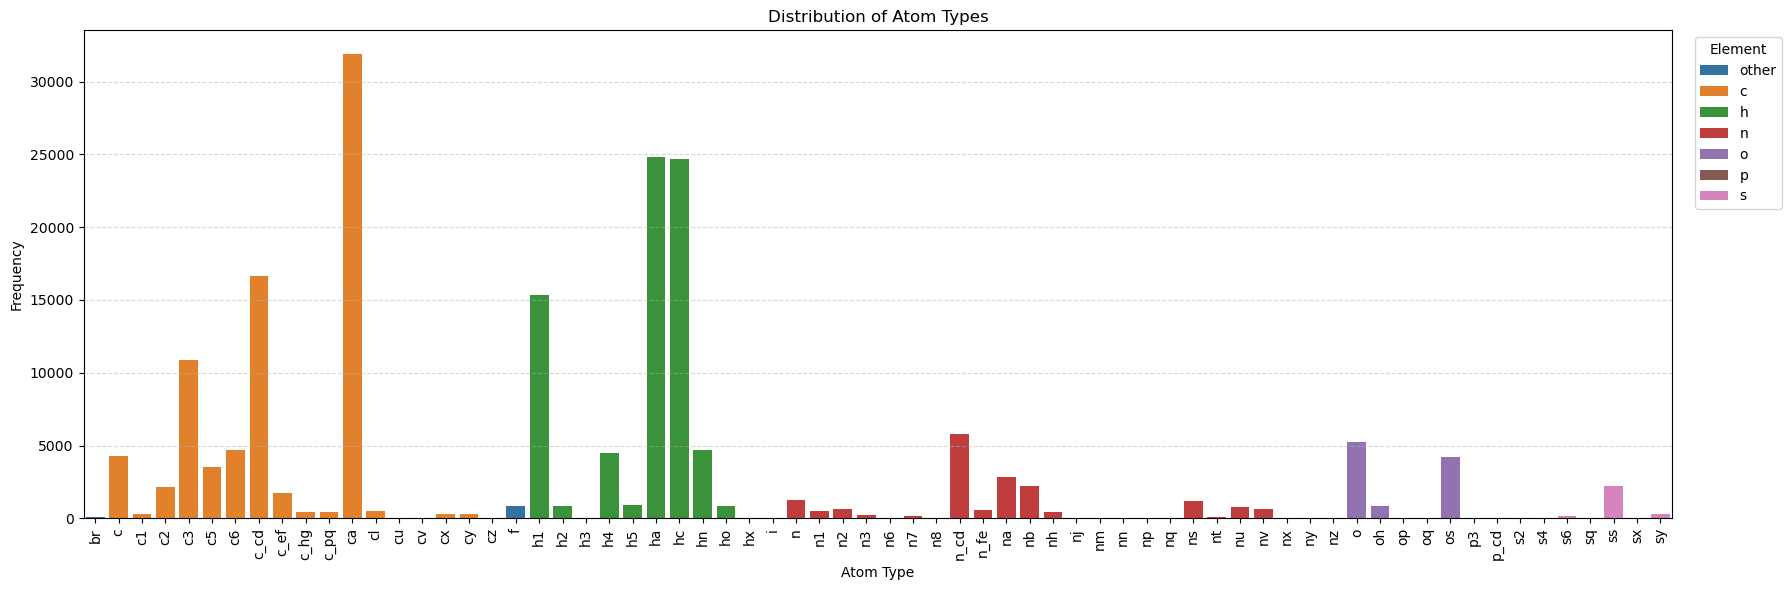

In [3]:
from atoMLtype.analysis.accuracy_counts import plot_atom_distribution

# Split Train and test dataset (90% train, 10% test)
train_size = int(0.90 * len(zinc_dataset))
test_size = len(zinc_dataset) - train_size
train_dataset, test_dataset = random_split(zinc_dataset, [train_size, test_size])

print("FULL DATASET (encoded):")
plot_atom_distribution(np.array(zinc_dataset_encoder.inverse_transform(zinc_dataset.encoded_labels)))

AtomBondMPNN - Number of parameters: 10985550
--- Fold 1/5 ---


Epoch 1: Train Loss = 3.4069, Val Loss = 0.1193
Epoch 6: Train Loss = 0.0366, Val Loss = 0.0327
Epoch 11: Train Loss = 0.0295, Val Loss = 0.0184
--- Fold 2/5 ---


Epoch 1: Train Loss = 0.0179, Val Loss = 0.0171
Epoch 6: Train Loss = 0.0120, Val Loss = 0.0194
Epoch 11: Train Loss = 0.0107, Val Loss = 0.0179
--- Fold 3/5 ---


Epoch 1: Train Loss = 0.0126, Val Loss = 0.0247
Epoch 6: Train Loss = 0.0074, Val Loss = 0.0300
Epoch 11: Train Loss = 0.0080, Val Loss = 0.0351
--- Fold 4/5 ---


Epoch 1: Train Loss = 0.0195, Val Loss = 0.0119
Epoch 6: Train Loss = 0.0093, Val Loss = 0.0108
Epoch 11: Train Loss = 0.0268, Val Loss = 0.0179
--- Fold 5/5 ---


Epoch 1: Train Loss = 0.0115, Val Loss = 0.0087
Epoch 6: Train Loss = 0.0104, Val Loss = 0.0041
Epoch 11: Train Loss = 0.0153, Val Loss = 0.0054


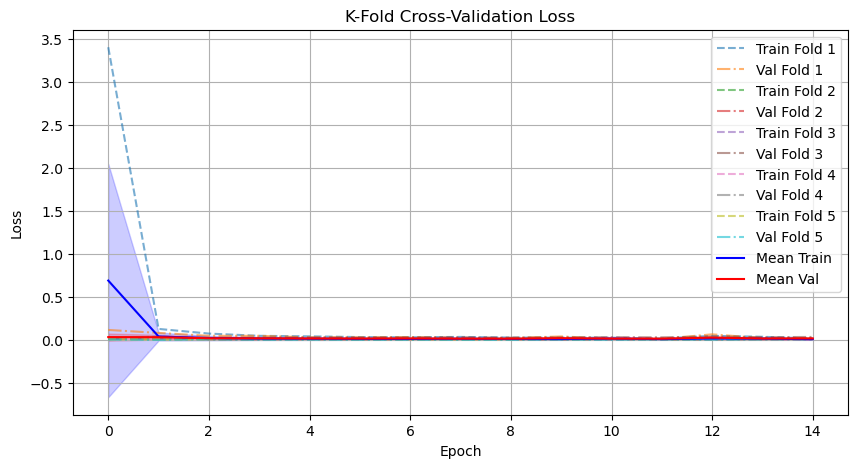

{'train_loss': [[3.4069226944348814,
   0.13134769391176918,
   0.0771041958505048,
   0.050851605820841625,
   0.044907762940172194,
   0.03658204664729362,
   0.033992567787675516,
   0.03831700947169529,
   0.030809716742730642,
   0.029603471141704467,
   0.029471061914491562,
   0.02004861146237472,
   0.050640230200662585,
   0.03991890799252587,
   0.01966536586693917],
  [0.017864713056338917,
   0.012947004657186565,
   0.012781098959503637,
   0.013000520534122696,
   0.013793420981662545,
   0.012039649879548501,
   0.013488136366743465,
   0.012543044061361926,
   0.01618134912197776,
   0.010823993434092724,
   0.010741418734055166,
   0.009591263250089193,
   0.010619192859594676,
   0.016977076579855966,
   0.01187971349976504],
  [0.012576421635329467,
   0.04460485765684138,
   0.011902231229591298,
   0.008573540645150778,
   0.00786865267741466,
   0.007435839129638252,
   0.0073912399125852304,
   0.0137003938624162,
   0.00875158427434742,
   0.007422220184512076,


In [4]:
from atoMLtype.models.GNN.DMPNNmodel import AtomBondMPNN
from atoMLtype.models.ModelTrainer import GNNTrainer

AtomMPNN_zinc = AtomBondMPNN(atom_input_dim=train_dataset[0].x.shape[1], 
                                      bond_input_dim=train_dataset[0].edge_attr.shape[1], 
                                      hidden_dim=512,
                                      encoder=zinc_dataset_encoder, 
                                      num_layers=10,
                                      use_attention=True)

trainer_AtomMPNN_zinc = GNNTrainer(AtomMPNN_zinc, 
                                   dataset=train_dataset, 
                                   batch_size=32, learning_rate=0.001,
                                   epochs=15, 
                                   k_folds=5, 
                                   random_seed=21)

trainer_AtomMPNN_zinc.train(verbose=True)



In [5]:
from atoMLtype.models.ModelEngine import ModelEngine

modelEngine_zinc = ModelEngine(model=AtomMPNN_zinc, 
                          dataset=test_dataset, 
                          device="cpu",
                          batch_size=32)

zinc_record = modelEngine_zinc.predict(analysis=True)


In [6]:
zinc_record.summary()

Prediction Summary: 18429/18518 correct (99.52% accuracy)
True label distribution: Counter({'ca': 3191, 'ha': 2464, 'hc': 2454, 'c_cd': 1714, 'h1': 1513, 'c3': 1102, 'n_cd': 620, 'o': 518, 'hn': 474, 'c6': 446, 'h4': 416, 'c': 409, 'os': 404, 'c5': 312, 'na': 275, 'ss': 239, 'nb': 213, 'c2': 186, 'c_ef': 147, 'n': 136, 'ns': 111, 'nu': 93, 'f': 91, 'oh': 84, 'ho': 84, 'h5': 77, 'h2': 75, 'n2': 63, 'n1': 62, 'nv': 60, 'cl': 57, 'n_fe': 55, 'c_hg': 51, 'nh': 45, 'c_pq': 42, 'cx': 36, 'cy': 35, 'sy': 29, 'c1': 25, 'n3': 24, 's6': 20, 'nt': 15, 'n7': 10, 'br': 7, 'hx': 6, 'sx': 4, 's4': 4, 'h3': 3, 'cv': 3, 'i': 2, 'sq': 2, 'n8': 2, 'nm': 2, 'oq': 1, 'cu': 1, 'nx': 1, 'nj': 1, 'ny': 1, 'op': 1})
Pred label distribution: Counter({'ca': 3187, 'ha': 2462, 'hc': 2460, 'c_cd': 1719, 'h1': 1524, 'c3': 1101, 'n_cd': 618, 'o': 520, 'hn': 474, 'c6': 451, 'h4': 418, 'os': 407, 'c': 407, 'c5': 312, 'na': 276, 'ss': 239, 'nb': 213, 'c2': 179, 'c_ef': 148, 'n': 136, 'ns': 111, 'nu': 91, 'f': 91, 'oh': 

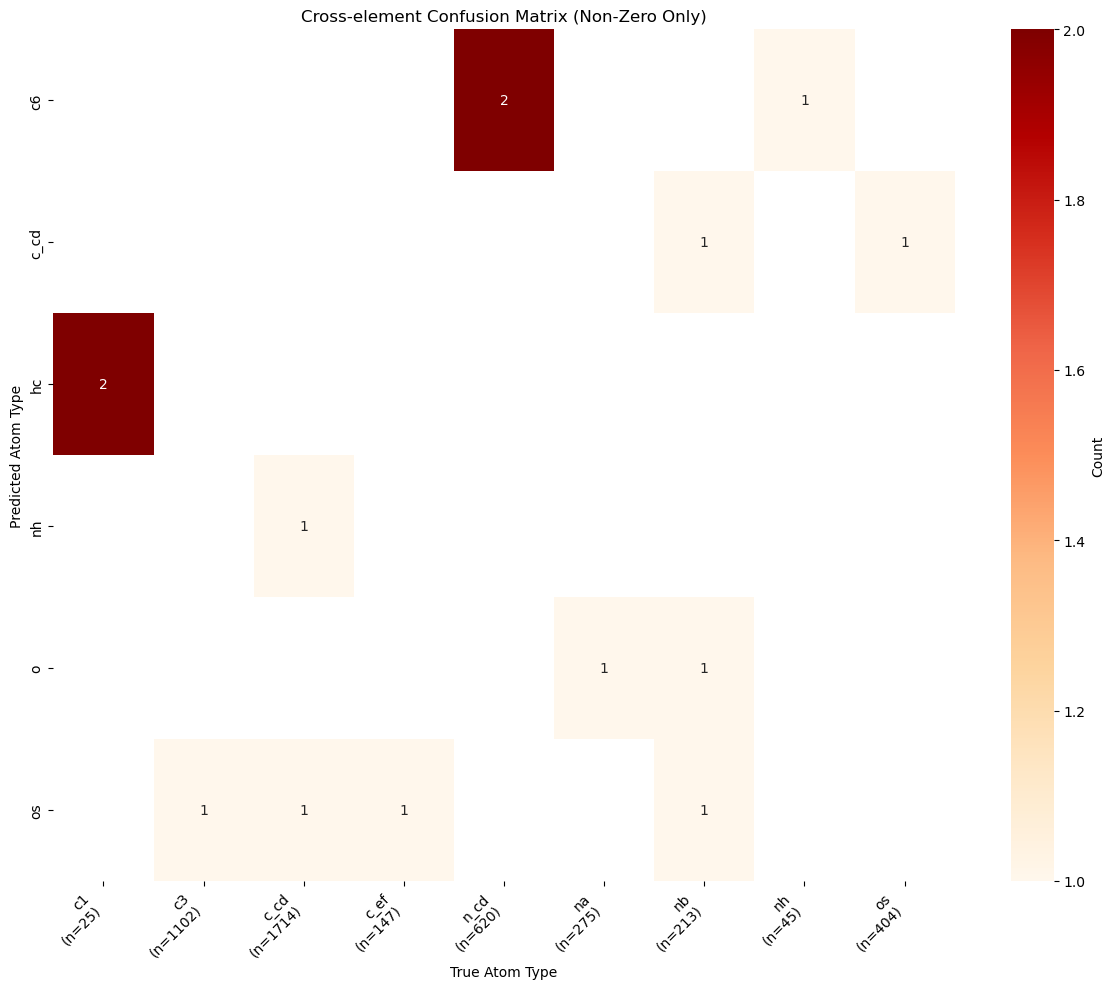

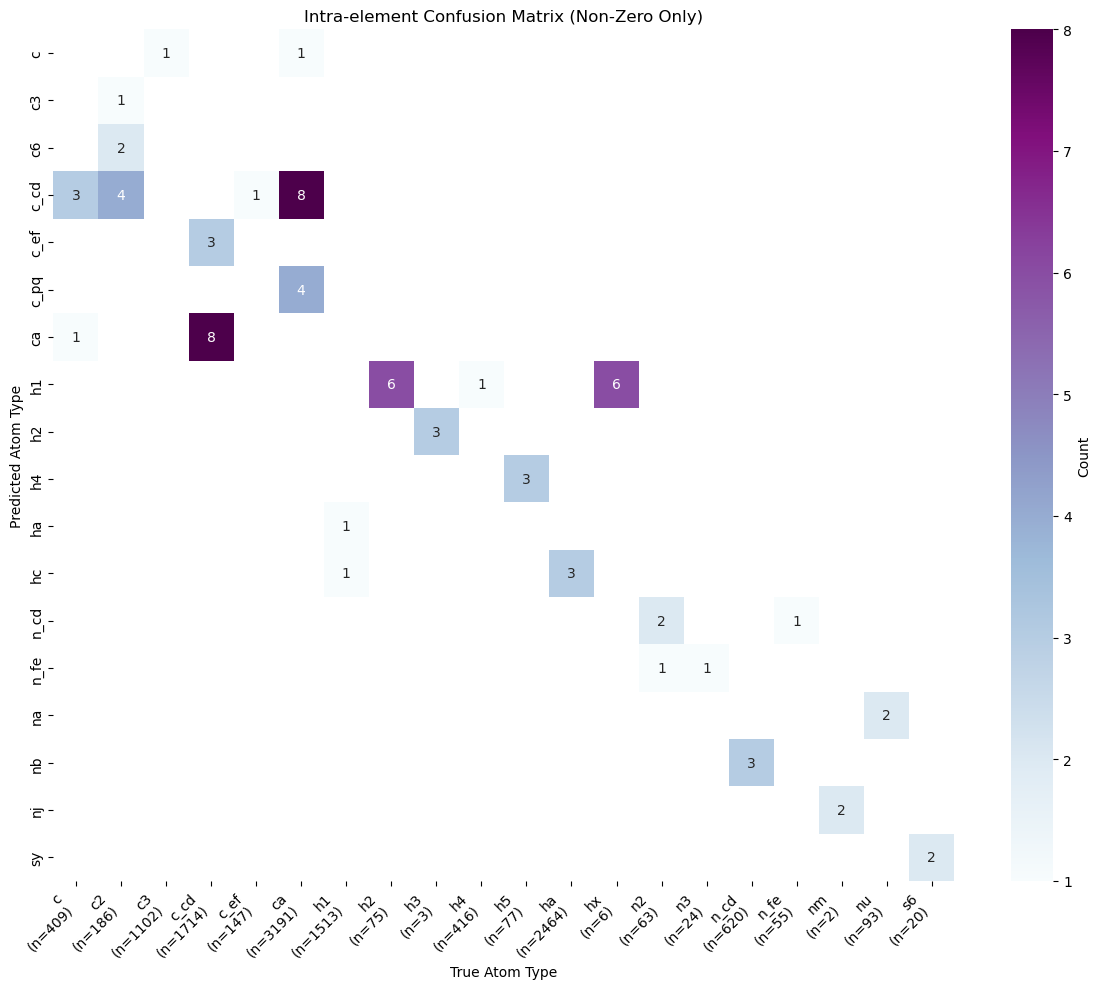

In [7]:
from atoMLtype.analysis.confusionMatrices import plot_full_confusion_matrices

plot_full_confusion_matrices(zinc_record)

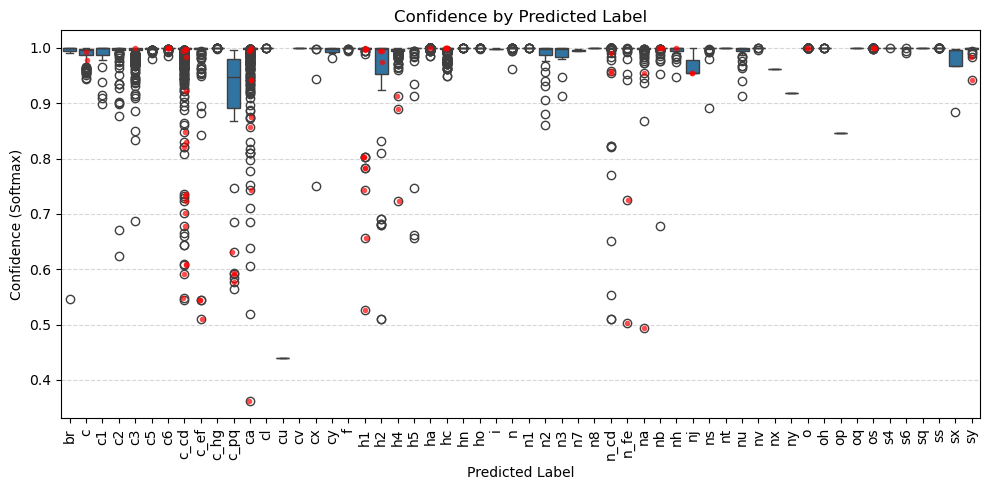

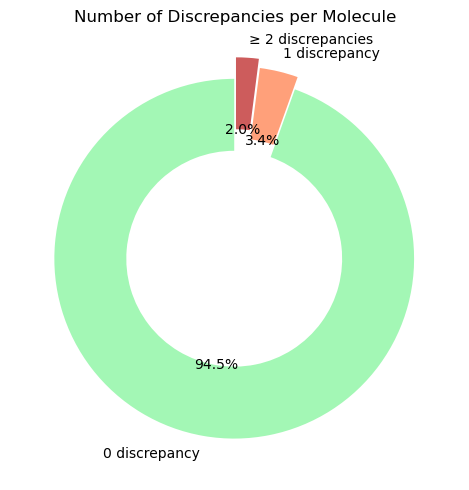

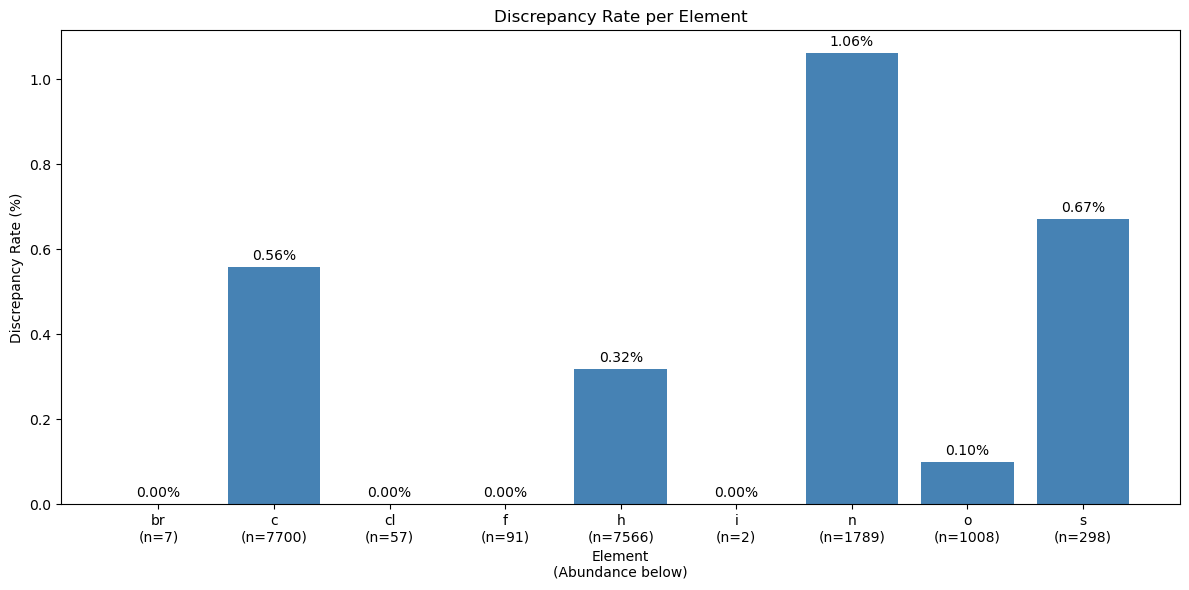

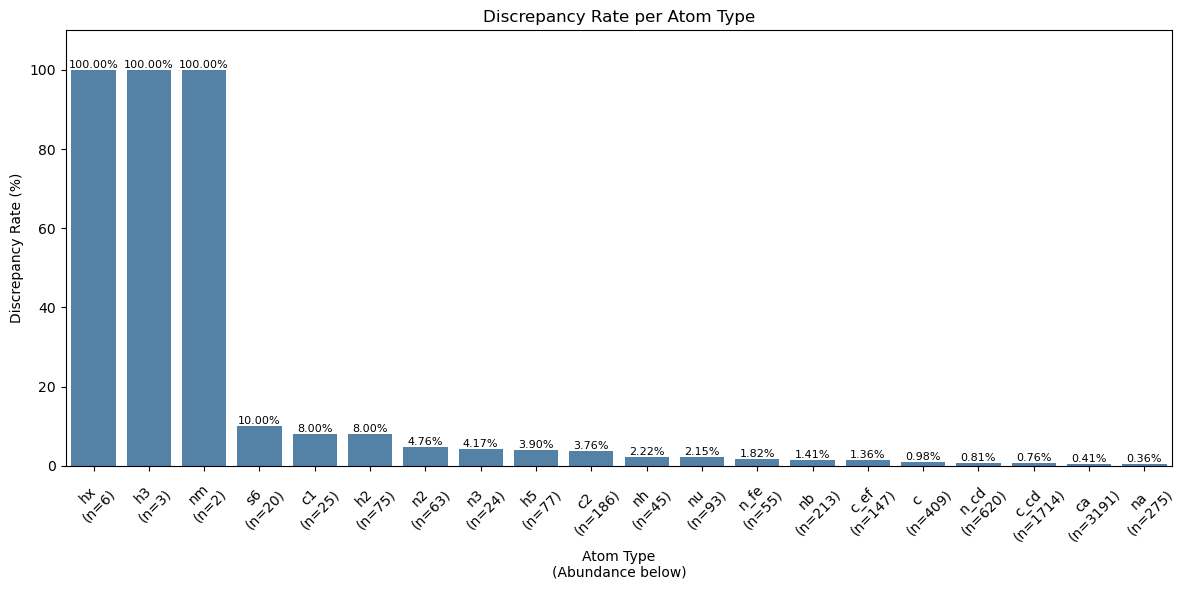

In [8]:
from atoMLtype.analysis.discrepancies import plot_confidence_by_pred_label, plot_discrepancy_distribution, plot_element_discrepancy_rate, plot_discrepancy_rate_by_atom_type


plot_confidence_by_pred_label(zinc_record, 
                              sort_by='alphabetical',
                              show_mismatch=True,
                              showfliers=True, 
                              figsize=(10, 5))

plot_discrepancy_distribution(zinc_record)

valid_elements = {
        "f", "cl", "br", "i", "c", "h", "n", "o", "s", "p"
    }

plot_element_discrepancy_rate(zinc_record, valid_elements)

plot_discrepancy_rate_by_atom_type(zinc_record)

/Users/brobello/Capstone_biovia/Biovia-1/atoMLtype/analysis/molecule_embeddings.py:103: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


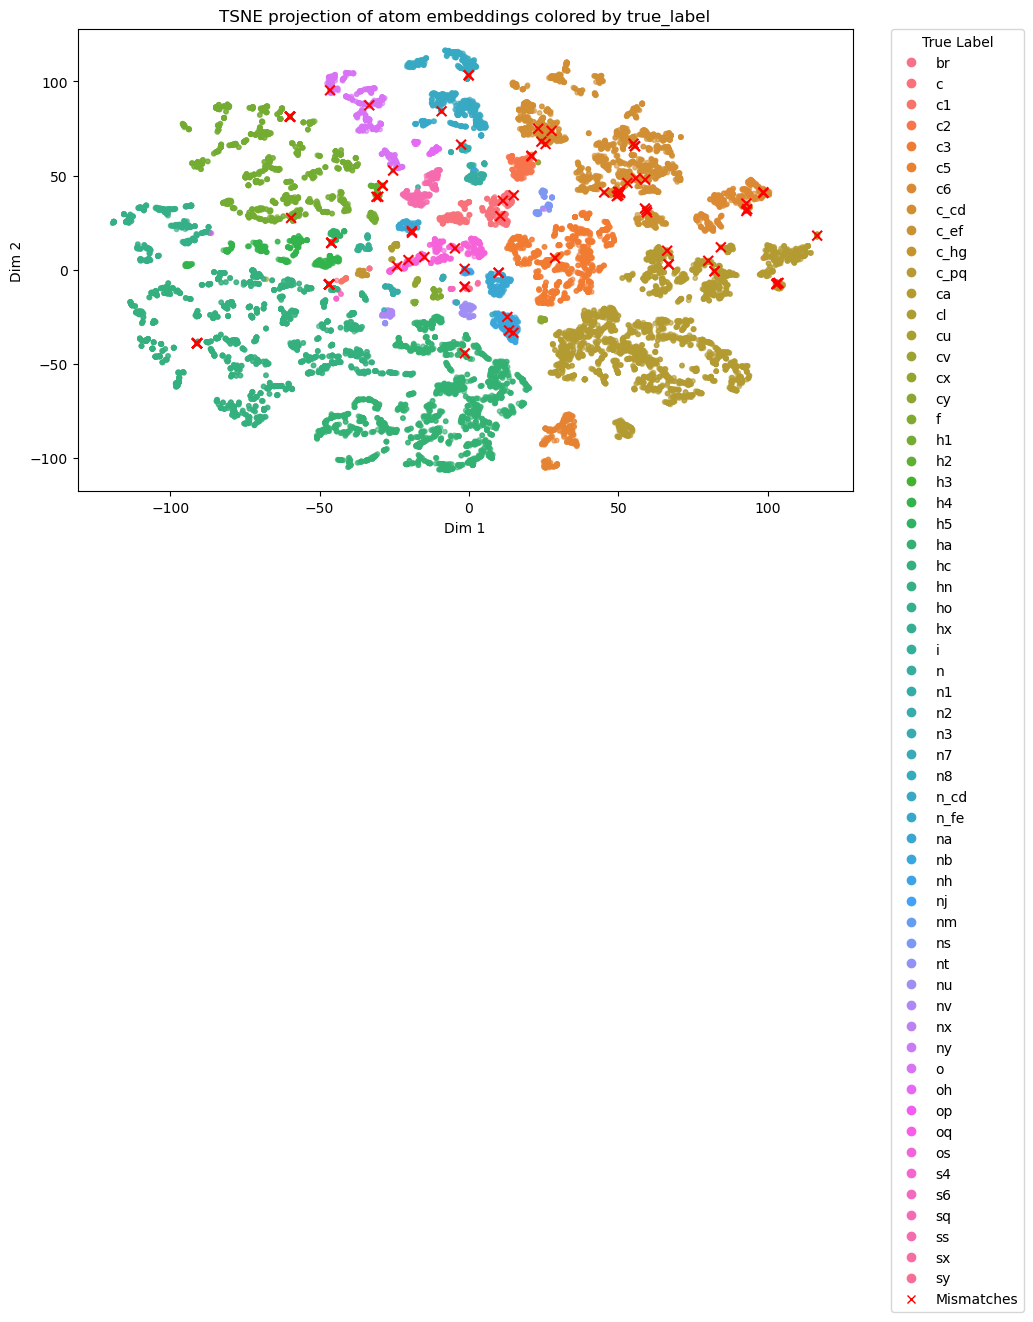

In [9]:
from atoMLtype.analysis.molecule_embeddings import visualize_prediction_embeddings

visualize_prediction_embeddings(
    pred_record=zinc_record,
    key='clf_embeddings',
    method='tsne'
)

In [10]:
len(zinc_record.mismatched_molecules)

35

ZINC05567136 atom 3, pred AT c_pq for ca
ZINC05567136 atom 4, pred AT c_pq for ca
ZINC05567136 atom 18, pred AT h1 for h2


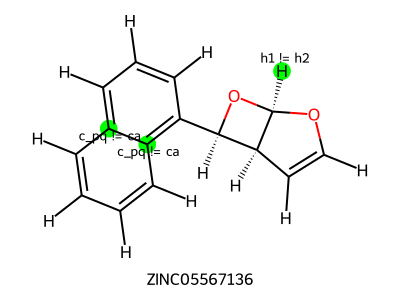

ZINC00344328 atom 17, pred AT h1 for h2


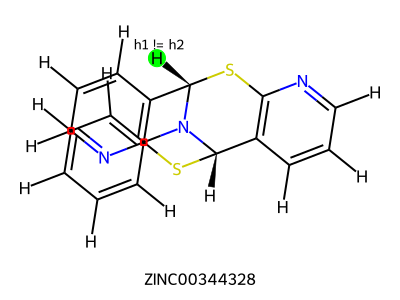

ZINC02476506 atom 22, pred AT h4 for h5


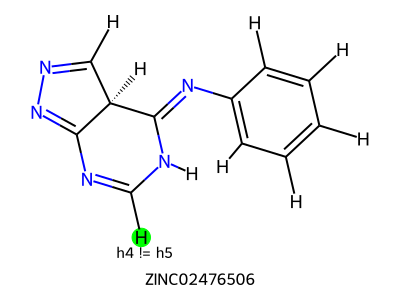

ZINC19832292 atom 1, pred AT c_cd for c2
ZINC19832292 atom 2, pred AT n_cd for n_fe
ZINC19832292 atom 6, pred AT na for nu


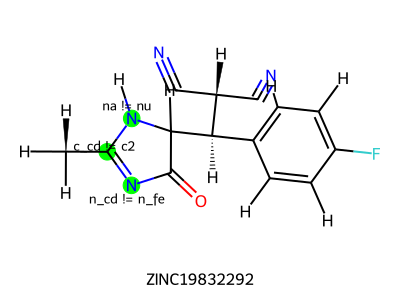

ZINC01625578 atom 7, pred AT ca for c_cd


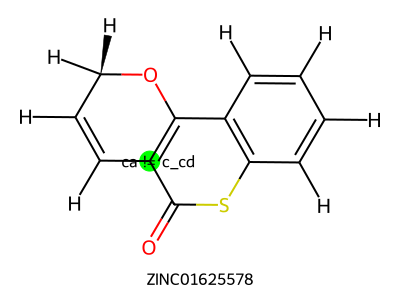

ZINC49398348 atom 10, pred AT c_cd for c
ZINC49398348 atom 19, pred AT h1 for hx
ZINC49398348 atom 23, pred AT h1 for hx
ZINC49398348 atom 24, pred AT h1 for hx
ZINC49398348 atom 25, pred AT h1 for hx
ZINC49398348 atom 26, pred AT h1 for hx
ZINC49398348 atom 27, pred AT h1 for hx


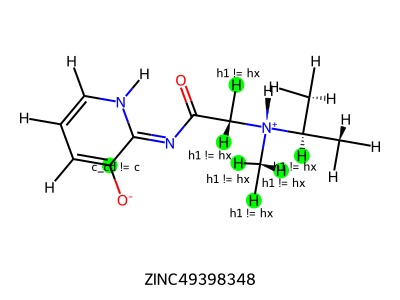

ZINC19328662 atom 12, pred AT h2 for h3


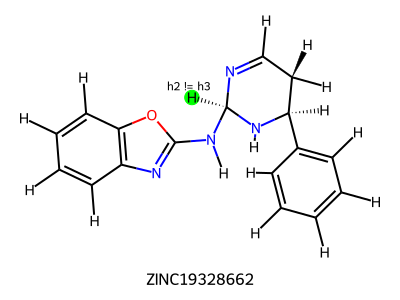

ZINC01580182 atom 1, pred AT c6 for nh
ZINC01580182 atom 2, pred AT os for c3
ZINC01580182 atom 3, pred AT c_cd for ca
ZINC01580182 atom 4, pred AT c_cd for nb
ZINC01580182 atom 5, pred AT c_cd for ca
ZINC01580182 atom 6, pred AT os for nb
ZINC01580182 atom 7, pred AT c for ca
ZINC01580182 atom 8, pred AT o for nb
ZINC01580182 atom 9, pred AT c_cd for os
ZINC01580182 atom 10, pred AT c for c3
ZINC01580182 atom 11, pred AT o for na
ZINC01580182 atom 12, pred AT os for c_cd
ZINC01580182 atom 13, pred AT nh for c_cd
ZINC01580182 atom 14, pred AT c6 for n_cd
ZINC01580182 atom 15, pred AT c6 for n_cd
ZINC01580182 atom 16, pred AT os for c_ef
ZINC01580182 atom 17, pred AT c6 for c2
ZINC01580182 atom 18, pred AT c6 for c2
ZINC01580182 atom 19, pred AT c3 for c2
ZINC01580182 atom 20, pred AT hc for c1
ZINC01580182 atom 21, pred AT hc for c1
ZINC01580182 atom 22, pred AT hc for h1
ZINC01580182 atom 23, pred AT ha for h1
ZINC01580182 atom 31, pred AT h1 for h4
ZINC01580182 atom 32, pred AT hc fo

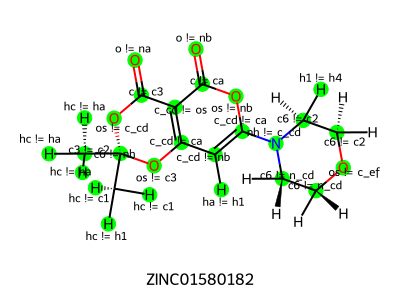

ZINC42750300 atom 12, pred AT c_cd for c2
ZINC42750300 atom 13, pred AT c_cd for c2


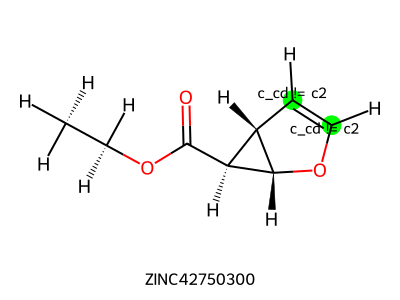

ZINC17043760 atom 4, pred AT h2 for h3


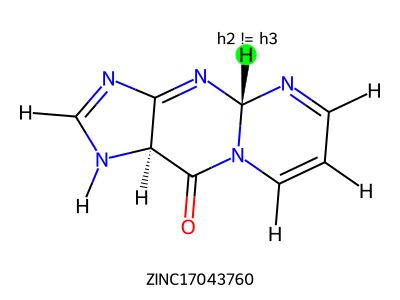

ZINC17020202 atom 5, pred AT sy for s6
ZINC17020202 atom 8, pred AT ca for c_cd
ZINC17020202 atom 9, pred AT ca for c_cd
ZINC17020202 atom 11, pred AT nb for n_cd
ZINC17020202 atom 12, pred AT ca for c
ZINC17020202 atom 14, pred AT nb for n_cd
ZINC17020202 atom 15, pred AT nb for n_cd


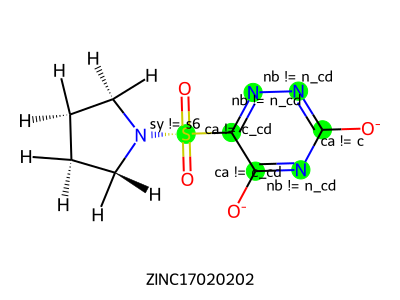

ZINC00481022 atom 12, pred AT c_cd for ca


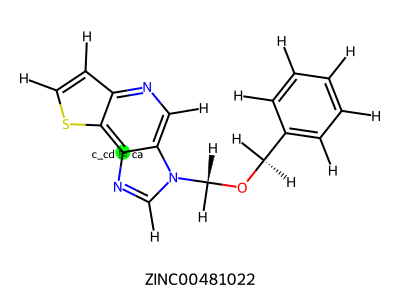

ZINC03160824 atom 6, pred AT ca for c_cd
ZINC03160824 atom 7, pred AT ca for c_cd


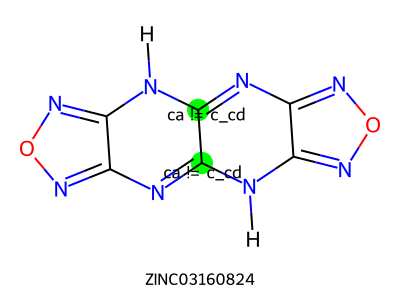

ZINC19328387 atom 3, pred AT c_pq for ca


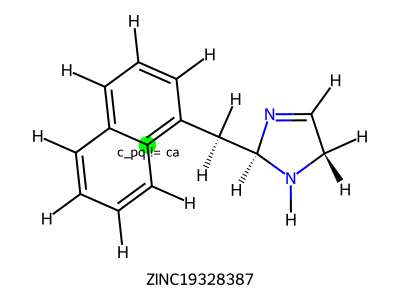

ZINC18190234 atom 7, pred AT c_cd for c_ef
ZINC18190234 atom 11, pred AT c_cd for ca
ZINC18190234 atom 13, pred AT c_cd for ca
ZINC18190234 atom 15, pred AT c_cd for ca
ZINC18190234 atom 16, pred AT c_cd for ca


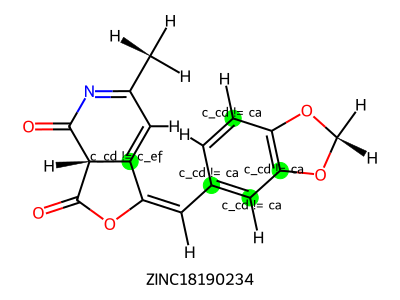

ZINC03846458 atom 3, pred AT ca for c_cd


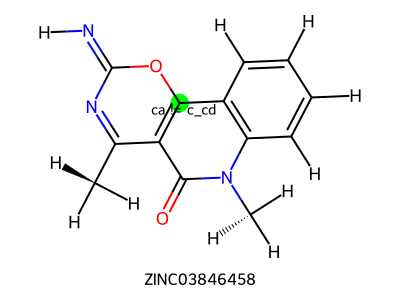

ZINC04642670 atom 4, pred AT n_fe for n3


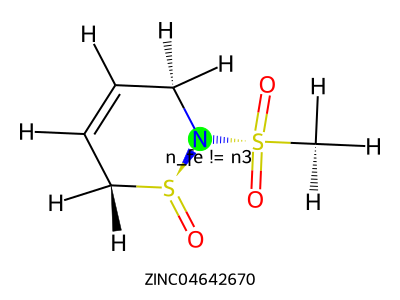

ZINC04994829 atom 11, pred AT h1 for h2
ZINC04994829 atom 12, pred AT h1 for h2


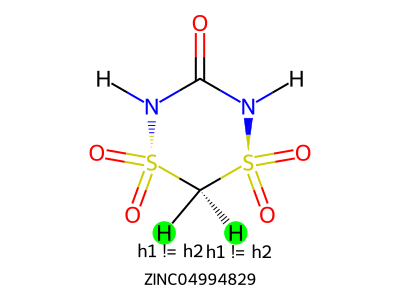

ZINC36559052 atom 21, pred AT h4 for h5


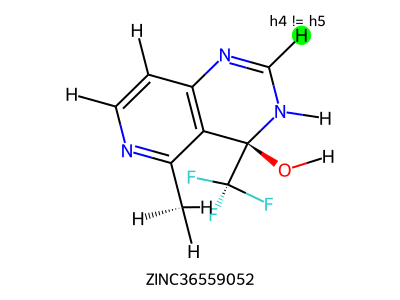

ZINC01563950 atom 13, pred AT h4 for h5


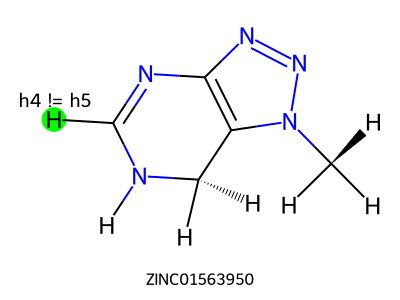

ZINC13281646 atom 9, pred AT ca for c_cd
ZINC13281646 atom 10, pred AT ca for c_cd
ZINC13281646 atom 15, pred AT c_ef for c_cd


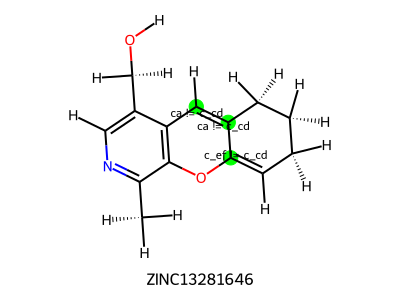

ZINC00054579 atom 11, pred AT h1 for h2


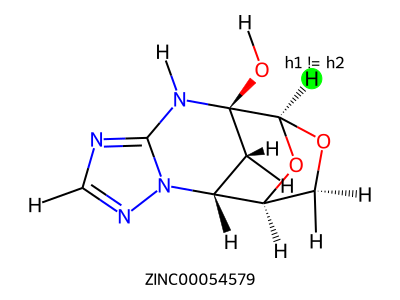

ZINC12941617 atom 20, pred AT c_cd for c


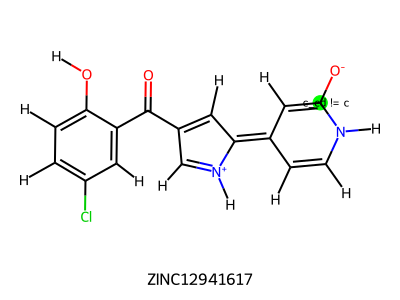

ZINC05385699 atom 24, pred AT h1 for h2


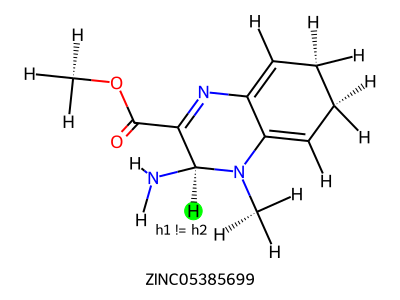

ZINC15912083 atom 23, pred AT c_cd for c2


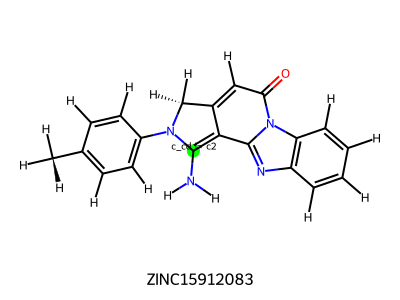

ZINC01565910 atom 5, pred AT c_cd for ca


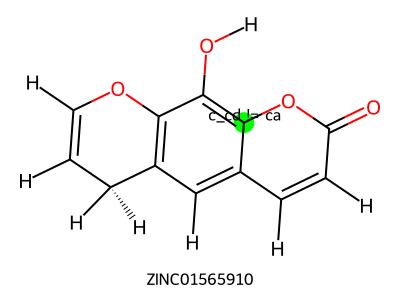

ZINC10297368 atom 20, pred AT na for nu


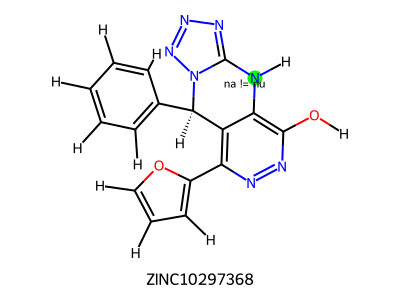

ZINC04975004 atom 3, pred AT c_ef for c_cd
ZINC04975004 atom 12, pred AT c_ef for c_cd


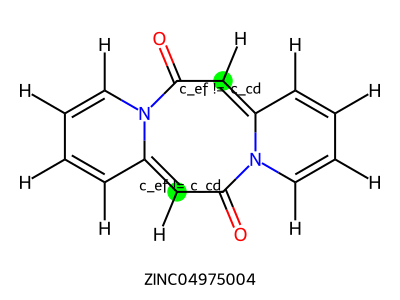

ZINC28467705 atom 11, pred AT n_fe for n2


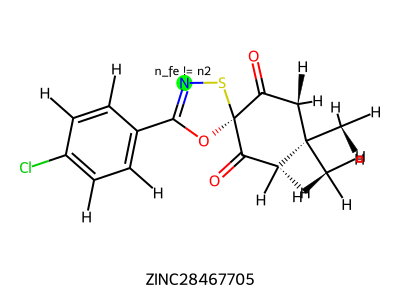

ZINC19615840 atom 12, pred AT h2 for h3


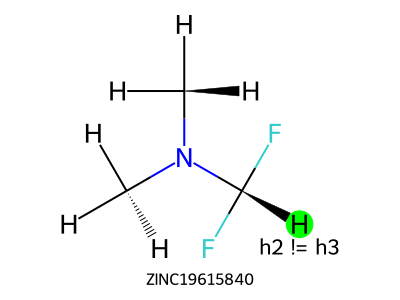

ZINC04156870 atom 1, pred AT c_cd for c


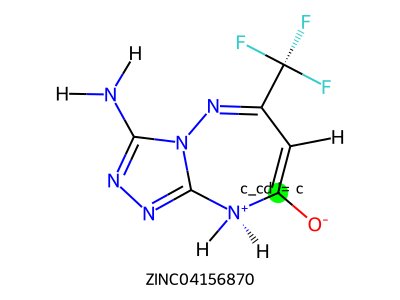

ZINC01670118 atom 7, pred AT nj for nm
ZINC01670118 atom 8, pred AT nj for nm


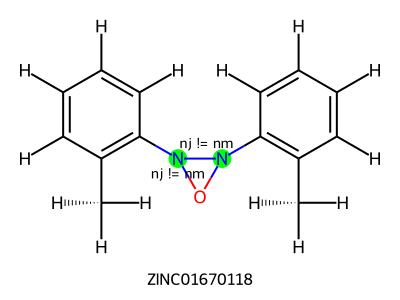

ZINC12610358 atom 4, pred AT c_pq for ca


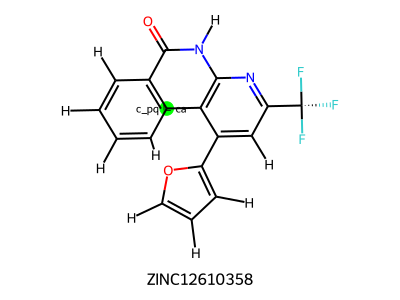

ZINC14241124 atom 16, pred AT n_cd for n2
ZINC14241124 atom 17, pred AT n_cd for n2


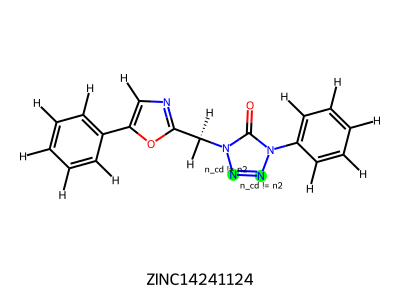

ZINC01679993 atom 7, pred AT sy for s6


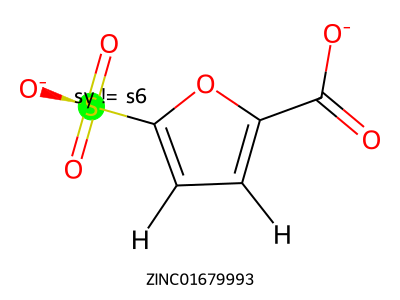

In [12]:
from atoMLtype.analysis.molecule_embeddings import draw_molecule_with_mismatches_labeled


for mol_name, atom_preds in zinc_record.mismatched_molecules.items():
    for atom_pred in atom_preds:
        if not atom_pred.pred_label == atom_pred.true_label:
            print(f"{mol_name} atom {atom_pred.atom_idx_in_mol}, pred AT {atom_pred.pred_label} for {atom_pred.true_label}")
    mol = zinc_dataset.get_mol(mol_name)

    img = draw_molecule_with_mismatches_labeled(mol, atom_preds)
    display(img)  # or img.save(f"{mol_name}_mismatch.png")